# Problem 17.6: Souvenir Sales
The dataset _SouvenirSales.csv_ contains monthly sales for a souvenir shop at a beach resort town in Queensland, Australia, between 1995--2001. [Source: Hyndman and Yang (2018).]

Back in 2001, the store wanted to use the data to forecast sales for the next 12 months (year 2002). They hired an analyst to generate forecasts. The analyst first partitioned the data into training and holdout sets, with the holdout set containing the last 12 months of data (year 2001). She then fit a regression model to sales, using the training set.


In [2]:
!pip install sktime

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 63.2 MB/s  0:00:00

   ---------------------------------------- 0/2 [scikit-base]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [sktime]
   -------------------- ------------------- 1/2 [skti


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import required packages for this chapter
import pandas as pd
import matplotlib.pyplot as plt
from sktime.split import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster
from sktime.utils.plotting import plot_series
import mlba

%matplotlib inline

__17.6.a__
Create a well-formatted time plot of the data.

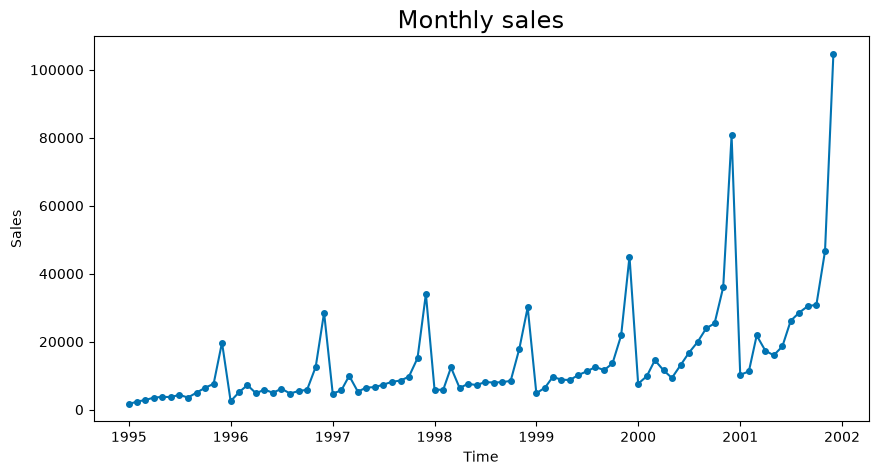

In [5]:
df = mlba.load_data('SouvenirSales.csv')
df_ts = pd.Series(df['Sales'].values, index=pd.to_datetime(df['Date'], format='%b-%y'), name='souvenir')

df_ts = df_ts.to_period('M')

fig,ax = plt.subplots(figsize=[10,5])

plot_series(df_ts, title='Monthly sales', x_label='Time', y_label='Sales', ax=ax)

plt.show()

__17.6.b__
Change the scale on the `x`-axis, or on the `y`-axis, or on both to log-scale in order to achieve a linear relationship. Select the time plot that seems most linear.

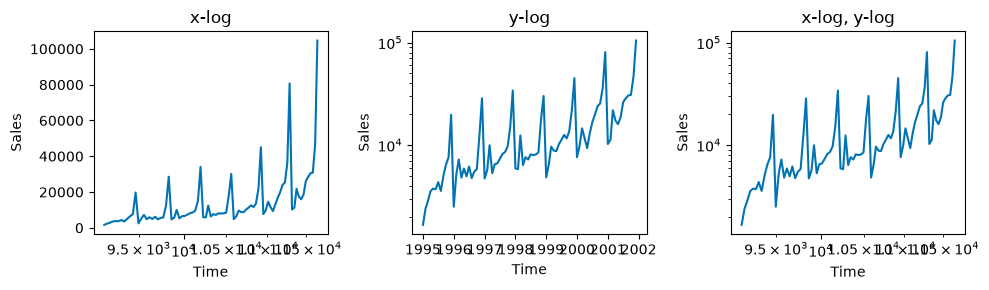

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=[10,3])

for ax in axes:
    plot_series(df_ts, markers=[None], ax=ax, x_label='Time', y_label='Sales')

axes[0].set_xscale('log')
axes[0].set_title('x-log')

axes[1].set_yscale('log')
axes[1].set_title('y-log')

axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title('x-log, y-log')

plt.tight_layout()
plt.show()

__17.6.c__
Comparing the time plots, what can be said about the type of trend in the data?

The trend is a positive trend because as time passes the values of sales goes up.

__17.6.d__
Why were the data partitioned? Partition the data into the training and holdout set as explained above.

Not sure what you mean exactly we haven't partitioned the data yet 

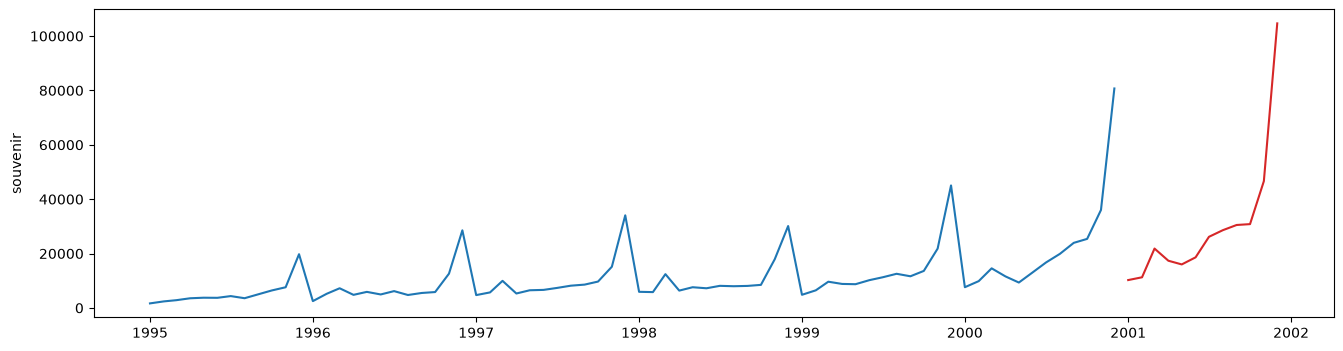

In [8]:
n_holdout = 12

train_ts, holdout_ts = temporal_train_test_split(df_ts, test_size=n_holdout)

plot_series(train_ts, holdout_ts, colors=['C0', 'C3'], markers=[None, None]);

__17.6.e__ Create naive forecasts for the year 2001 using either the last value in the training set or the last  year. Compare the MAPE and RMSE values; what do you observe?

C:\Users\samsc\anaconda3\Lib\site-packages\sktime\forecasting\base\_base.py:169: FutureWarning: The default of config ``remember_data`` will change from ``True`` to ``False`` in sktime 1.3.0. After 1.3.0, ``BaseForecaster`` will no longer store incremental data in ``_X`` and ``_y`` by default. To silence this warning and adopt the new default early, set ``remember_data=False`` via ``set_config``. For forecasters that do not have update natively supported, i.e., the capability:update tag is not True, the default ``update`` will not refit. To keep storing incremental data and refitting on every update after the default change, set ``remember_data=True`` explicitly, or use ``UpdateRefitsEvery`` with ``refit_interval=0``.
  warn(
C:\Users\samsc\anaconda3\Lib\site-packages\sktime\forecasting\base\_base.py:169: FutureWarning: The default of config ``remember_data`` will change from ``True`` to ``False`` in sktime 1.3.0. After 1.3.0, ``BaseForecaster`` will no longer store incremental data in

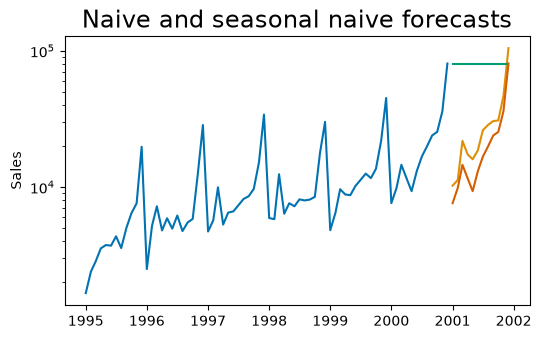

In [9]:
naive_forecaster = NaiveForecaster(strategy='last')
naive_forecaster.fit(train_ts)

seasonal_forecaster = NaiveForecaster(strategy='last', sp=12)
seasonal_forecaster.fit(train_ts)

fig,ax = plt.subplots(figsize=[6, 3.5])

plot_series(train_ts, holdout_ts, naive_forecaster.predict(holdout_ts.index),
            seasonal_forecaster.predict(holdout_ts.index), markers=[None]*4,
            title='Naive and seasonal naive forecasts', y_label='Sales', ax=ax)

ax.set_yscale('log')

plt.show()

In [10]:
pd.DataFrame({'Naive': mlba.regressionMetrics(y_true=holdout_ts, y_pred=naive_forecaster.predict(holdout_ts.index)),
              'Seasonal Naive': mlba.regressionMetrics(y_true=holdout_ts, y_pred=seasonal_forecaster.predict(holdout_ts.index))}).round(0)

,Naive,Seasonal Naive
ME,-50500.0,7828.0
RMSE,56099.0,9542.0
MAE,54490.0,7828.0
MPE,-287.0,27.0
MAPE,291.0,27.0
